In [3]:
#Module 2 
#Demo Lab : Part A

import sqlite3 as sq3
import pandas.io.sql as pds
import pandas as pd

# Define the path to the database
path = r"C:\Users\weelcome\Documents\classic_rock.db"

# Establish a connection to the database
con = sq3.Connection(path)

query = '''
SELECT * 
FROM rock_songs;
'''
# Execute the query
observations = pds.read_sql(query, con)
print(observations.head())

query2 = '''
SELECT Artist, Release_Year, COUNT(*) AS num_songs, AVG(PlayCount) AS avg_plays  
    FROM rock_songs
    GROUP BY Artist, Release_Year
    ORDER BY num_songs desc;
'''

# Execute the query
observations2 = pds.read_sql(query2, con)
print(observations2.head())

observations_generator = pds.read_sql(query,
                            con,
                            coerce_float=True, # Doesn't efefct this dataset, because floats were correctly parsed
                            parse_dates=['Release_Year'], # Parse `Release_Year` as a date
                            chunksize=5 # Allows for streaming results as a series of shorter tables
                           )

for index, observations in enumerate(observations_generator):
    if index < 5:
        print(f'Observations index: {index}'.format(index))
        display(observations)



                     Song        Artist  Release_Year  PlayCount
0        Caught Up in You   .38 Special        1982.0         82
1         Hold On Loosely   .38 Special        1981.0         85
2  Rockin' Into the Night   .38 Special        1980.0         18
3       Art For Arts Sake          10cc        1975.0          1
4              Kryptonite  3 Doors Down        2000.0         13
         Artist  Release_Year  num_songs  avg_plays
0   The Beatles        1967.0         23   6.565217
1  Led Zeppelin        1969.0         18  21.000000
2   The Beatles        1965.0         15   3.800000
3   The Beatles        1968.0         13  13.000000
4   The Beatles        1969.0         13  15.000000
Observations index: 0


,Song,Artist,Release_Year,PlayCount
0,Caught Up in You,.38 Special,1970-01-01 00:33:02,82
1,Hold On Loosely,.38 Special,1970-01-01 00:33:01,85
2,Rockin' Into the Night,.38 Special,1970-01-01 00:33:00,18
3,Art For Arts Sake,10cc,1970-01-01 00:32:55,1
4,Kryptonite,3 Doors Down,1970-01-01 00:33:20,13


Observations index: 1


,Song,Artist,Release_Year,PlayCount
0,Loser,3 Doors Down,1970-01-01 00:33:20,1
1,When I'm Gone,3 Doors Down,1970-01-01 00:33:22,6
2,What's Up?,4 Non Blondes,1970-01-01 00:33:12,3
3,Take On Me,a-ha,1970-01-01 00:33:05,1
4,Back In Black,AC/DC,1970-01-01 00:33:00,97


Observations index: 2


,Song,Artist,Release_Year,PlayCount
0,Big Gun,AC/DC,1970-01-01 00:33:13,6
1,Dirty Deeds Done Dirt Cheap,AC/DC,1970-01-01 00:32:56,85
2,For Those About To Rock,AC/DC,1970-01-01 00:33:01,46
3,Hard As A Rock,AC/DC,1970-01-01 00:33:15,1
4,Have a Drink On Me,AC/DC,1970-01-01 00:33:00,39


Observations index: 3


,Song,Artist,Release_Year,PlayCount
0,Hells Bells,AC/DC,1970-01-01 00:33:00,74
1,Highway To Hell,AC/DC,1970-01-01 00:32:59,92
2,It's A Long Way To The Top,AC/DC,1970-01-01 00:32:55,39
3,Jailbreak,AC/DC,1970-01-01 00:33:04,1
4,Let There Be Rock,AC/DC,1970-01-01 00:32:57,3


Observations index: 4


,Song,Artist,Release_Year,PlayCount
0,Night Prowler,AC/DC,1970-01-01 00:32:59,1
1,Rock and Roll Ain't Noise Pollution,AC/DC,1970-01-01 00:33:00,21
2,Shot Down In Flames,AC/DC,1970-01-01 00:32:59,2
3,T.N.T.,AC/DC,1970-01-01 00:32:55,66
4,Thunderstruck,AC/DC,1970-01-01 00:33:10,34


In [3]:
#Module 2
#Demo Lab : Part B

import sqlite3 as sq3
import pandas.io.sql as pds
import pandas as pd

path=r"C:\Users\weelcome\Documents\baseball.db"

con=sq3.Connection(path)

query='''SELECT*FROM allstarfull;'''
observations=pds.read_sql(query,con)
print(observations.head())

all_tables=pd.read_sql('SELECT*FROM sqlite_master',con)
print(all_tables)

best_query = """
SELECT playerID, sum(GP) AS num_games_played, AVG(startingPos) AS avg_starting_position
    FROM allstarfull
    GROUP BY playerID
    ORDER BY num_games_played DESC, avg_starting_position ASC
    LIMIT 3
"""
best = pd.read_sql(best_query, con)
print(best.head())




   index   playerID  yearID  gameNum        gameID teamID lgID   GP  \
0      0  gomezle01    1933        0  ALS193307060    NYA   AL  1.0   
1      1  ferreri01    1933        0  ALS193307060    BOS   AL  1.0   
2      2  gehrilo01    1933        0  ALS193307060    NYA   AL  1.0   
3      3  gehrich01    1933        0  ALS193307060    DET   AL  1.0   
4      4  dykesji01    1933        0  ALS193307060    CHA   AL  1.0   

   startingPos  
0          1.0  
1          2.0  
2          3.0  
3          4.0  
4          5.0  
    type                  name     tbl_name  rootpage  \
0  table           allstarfull  allstarfull         2   
1  index  ix_allstarfull_index  allstarfull         3   
2  table               schools      schools        26   
3  index      ix_schools_index      schools        31   
4  table               batting      batting        99   
5  index      ix_batting_index      batting       100   

                                                 sql  
0  CREATE TABLE 

In [4]:
!pip install seaborn scipy
!pip install --upgrade seaborn scipy



Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ------ --------------------------------- 10.2/60.8 kB ? eta -:--:--
     ------------------- ------------------ 30.7/60.8 kB 435.7 kB/s eta 0:00:01
     -------------------------------------- 60.8/60.8 kB 463.5 kB/s eta 0:00:00
   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   ------------------------------------- -- 276.5/294.9 kB 5.7 MB/s eta 0:00:01
   ---------------------------------------- 294.9/294.9 kB 3.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/44.7 MB ? eta -:--:--
   ---------------------------------------- 0.4/44.7 MB 13.4 MB/s eta 0:00:04
    --------------------------------------- 0.8/44.7 MB 10.8 MB/s eta 0:00:05
   - -----

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.


In [5]:
import pandas as pd
import numpy as np 

import seaborn as sns 
import matplotlib.pylab as plt
%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from scipy.stats import norm
from scipy import stats

In [12]:
path=r"C:\Users\weelcome\Downloads\housing.csv"
housing=pd.read_csv(path)
print(housing.head(5))
print(housing.info()) #gives the index, columns, non - null values , dtype, memory usage
print(housing['PID'].describe()) #gives statistical info like count mean median percentile
print(housing['Sale Condition'].value_counts()) #counts unique values , sorts by frequency(descending) and excludes Nans

   Unnamed: 0  Order        PID  MS SubClass MS Zoning  Lot Frontage  \
0           0      1  526301100           20        RL         141.0   
1           1      2  526350040           20        RH          80.0   
2           2      3  526351010           20        RL          81.0   
3           3      4  526353030           20        RL          93.0   
4           4      5  527105010           60        RL          74.0   

   Lot Area Street Alley Lot Shape  ... Pool Area Pool QC  Fence Misc Feature  \
0     31770   Pave   NaN       IR1  ...         0     NaN    NaN          NaN   
1     11622   Pave   NaN       Reg  ...         0     NaN  MnPrv          NaN   
2     14267   Pave   NaN       IR1  ...         0     NaN    NaN         Gar2   
3     11160   Pave   NaN       Reg  ...         0     NaN    NaN          NaN   
4     13830   Pave   NaN       IR1  ...         0     NaN  MnPrv          NaN   

  Misc Val Mo Sold Yr Sold Sale Type Sale Condition  SalePrice  
0        0     

skewness= 1.7435000757376466
Log transformed skewness= -0.014793439509736364


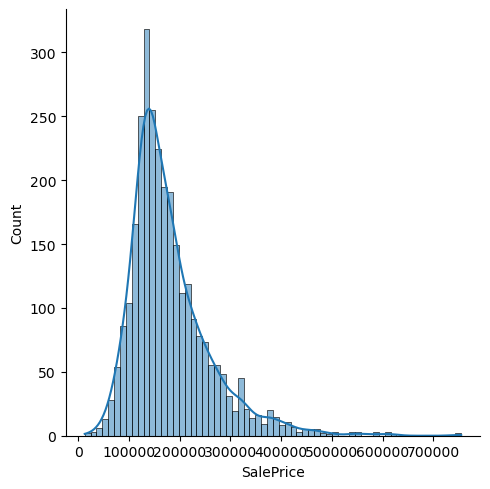

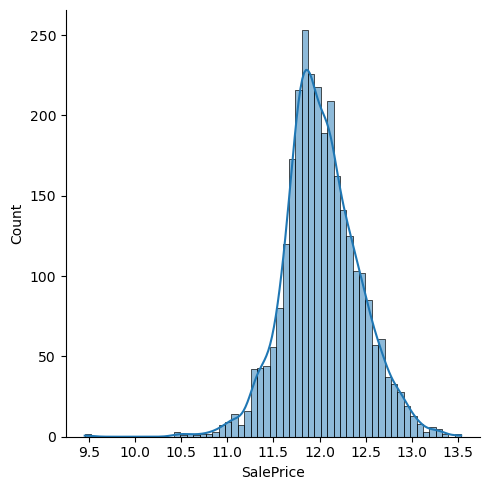

In [21]:
#Log Transformation
#displot function- plot the disturbution of univariate sets. histogram and KDE(kernel density estimate)
#bell curve 
sp_untransformed=sns.displot(housing['SalePrice'],kde=True)#deviates from normal disturbution. It has a longer tail to right so POSITIVE SKEW.
#Skewness-measureness of asymmetry of disturbution , kurtosis - pointedness of a peak 
#lets measure the skew
print("skewness=",housing['SalePrice'].skew())

#Range of skewness for a fairly symmetrical bell curve distribution is between -0.5 and 0.5
#moderate skewness is -0.5 to -1.0 and 0.5 to 1.0
#highly skewed is <-1.0 and >1.0

log_transformed=np.log(housing['SalePrice'])
sp_transformed=sns.displot(log_transformed,kde=True)
print("Log transformed skewness=",log_transformed.skew())




Skewness of untransformed data= 12.820898171092681
Skewness of untransformed data= -0.4988609894343381


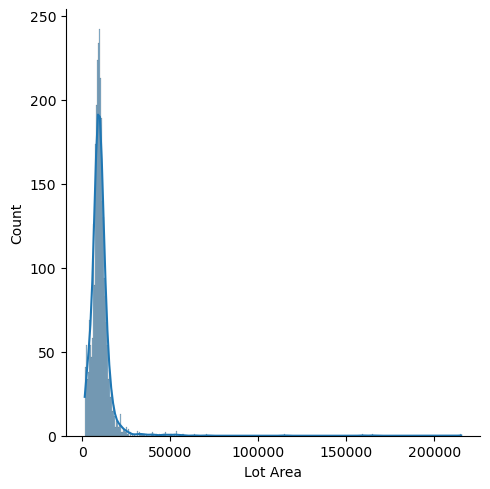

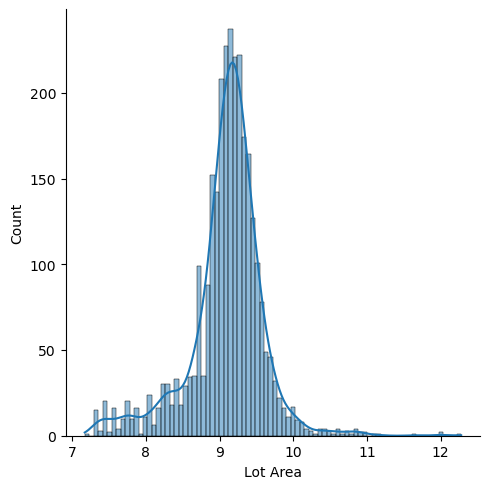

In [29]:
#excercise on log transform
la_untransformed=sns.displot(housing['Lot Area'],kde=True)
print("Skewness of untransformed data=",housing['Lot Area'].skew())
la_log=np.log(housing['Lot Area'])
la_transformed=sns.displot(la_log,kde=True)
print("Skewness of untransformed data=",la_log.skew())




In [35]:
#Handling duplicates
#.duplicated() - used to identify duplicate rows in a dataframe - return boolean value

duplicate=housing[housing.duplicated(['PID'])]
duplicate
dup_removed=housing.drop_duplicates()
dup_removed

#excercise 3
duplicate1=housing[housing.duplicated(['Order'])]
duplicate1
removed_sub=housing.drop_duplicates(subset=['Order'])
removed_sub


,Unnamed: 0,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2926,2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


Text(0.5, 1.0, 'Total Missing Value')

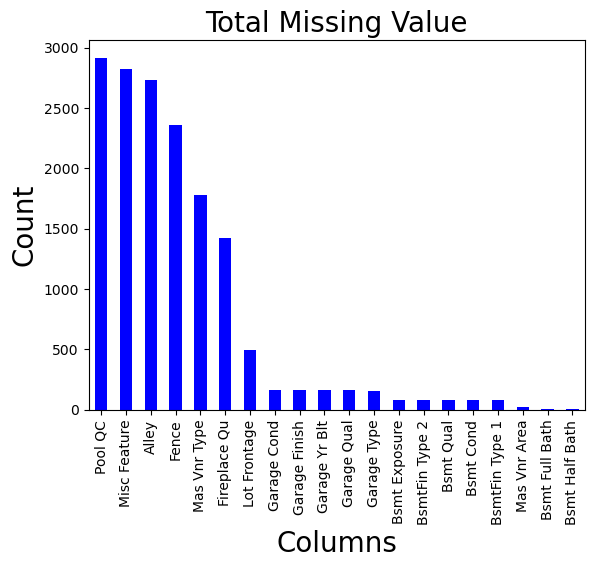

In [41]:
#Handling missing values
#isnull() is used for checking missing or null values 
total=housing.isnull().sum().sort_values(ascending=False)
total_select=total.head(20)
total_select.plot(kind='bar',color='blue',fontsize=10)
plt.xlabel("Columns",fontsize=20)
plt.ylabel("Count",fontsize=20)
plt.title("Total Missing Value",fontsize=20)







In [45]:
#dropna() to drop null values
#fillna()-replace by median , mean
housing.dropna(subset=['Lot Frontage'])
housing.drop("Lot Frontage",axis=1)
median = housing["Lot Frontage"].median()
housing["Lot Frontage"].fillna(median, inplace = True)
housing.tail()






,Unnamed: 0,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
2925,2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2926,2927,923276100,20,RL,68.0,8885,Pave,NaN,IR1,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000
2929,2929,2930,924151050,60,RL,74.0,9627,Pave,NaN,Reg,...,0,NaN,NaN,NaN,0,11,2006,WD,Normal,188000


In [47]:
#excercise 4
mean= housing["Mas Vnr Area"].mean()
housing["Mas Vnr Area"].fillna(mean, inplace = True)
housing.tail()

,Unnamed: 0,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
2925,2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2926,2927,923276100,20,RL,68.0,8885,Pave,NaN,IR1,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000
2929,2929,2930,924151050,60,RL,74.0,9627,Pave,NaN,Reg,...,0,NaN,NaN,NaN,0,11,2006,WD,Normal,188000


In [24]:
#Module 3 
#Demo Lab
import pandas as pd
import numpy as np

path=r"C:\Users\weelcome\Documents\iris_data.csv"
iris=pd.read_csv(path)
print(iris.head())
print(iris.shape[0])#no of rows
print(iris.shape[1])#no of columns
print(iris.columns)#column names
print(iris.dtypes)#dtypes


#replace iris with ' ' 
iris['species']=iris.species.str.replace('Iris-','')
iris.head()

#value_counts()
iris.species.value_counts()

#describe()
stats_df=iris.describe() #we see that the median is not described here as 50% is the median
stats_df.loc['range']=stats_df.loc['max']-stats_df.loc['min']

out_fields=['mean','25%','50%','75%','range']
stats_df=stats_df.loc[out_fields]
stats_df.rename({'50%':'median'},inplace=True)
print(stats_df) #now median is described

#mean calculation 
print(iris.groupby('species').mean())
print(iris.groupby('species').median())


   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
150
5
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object
        sepal_length  sepal_width  petal_length  petal_width
mean        5.843333        3.054      3.758667     1.198667
25%         5.100000        2.800      1.600000     0.300000
median      5.800000        3.000      4.350000     1.300000
75%         6.400000        3.300      5.100000     1.800000
range       3.600000        2.400      5.900000     2.400000


Axes(0.125,0.11;0.775x0.77)


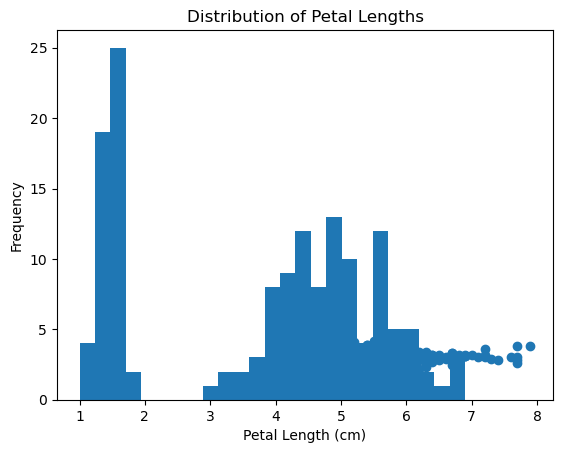

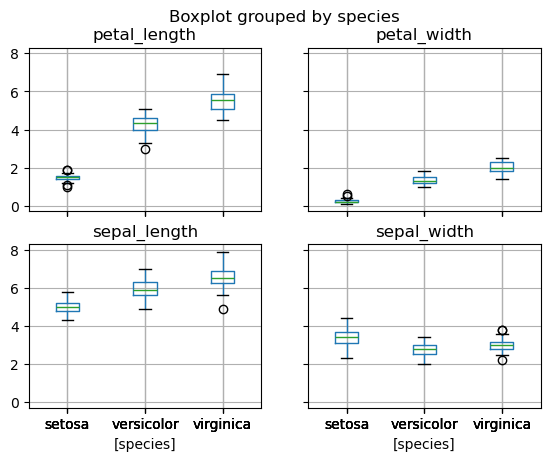

In [29]:
#plotting using matplotlib
import matplotlib.pyplot as plt
ax=plt.axes()
print(ax.scatter(iris.sepal_length,iris.sepal_width))
ax.set(xlabel='sepal length(cm)',ylabel='Sepal Width (cm)',
       title='Sepal Length vs Width');

ax1=iris.petal_length.plot.hist(bins=25)
print(ax1)
ax1.set(xlabel='Petal Length (cm)', 
       ylabel='Frequency',
       title='Distribution of Petal Lengths');

iris.boxplot(by='species');


In [5]:
#Practice excercise EDA Module 3
import pandas as pd

gasoline = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0232EN-SkillsNetwork/asset/18100001.csv")
print(gasoline.head())
print(gasoline.shape,gasoline.info(),gasoline.columns,gasoline.isnull().sum())

#data wrangling
data=(gasoline[['REF_DATE','GEO','Type of fuel','VALUE']]).rename(columns={"REF_DATE" : "DATE", "Type of fuel" : "TYPE"})
data

#string split - splits string recprds by  a comma
data[['City', 'Province']] = data['GEO'].str.split(',', n=1, expand=True)
data.head()

#datetime format
data['DATE']=pd.to_datetime(data['DATE'],format='%b-%y') #month year format
data['Month']=data['DATE'].dt.month_name().str.slice(stop=3)#gets only first 3 characters from month like JAN,FEB,MAR
data['Year']=data['DATE'].dt.year
print(data.head())




  REF_DATE                                                GEO         DGUID  \
0   Jan-79              St. John's, Newfoundland and Labrador  2011S0503001   
1   Jan-79  Charlottetown and Summerside, Prince Edward Is...           NaN   
2   Jan-79                               Halifax, Nova Scotia  2011S0503205   
3   Jan-79                          Saint John, New Brunswick  2011S0503310   
4   Jan-79                                     Québec, Quebec  2011S0503421   

                                        Type of fuel              UOM  UOM_ID  \
0  Regular unleaded gasoline at full service fill...  Cents per litre      57   
1  Regular unleaded gasoline at full service fill...  Cents per litre      57   
2  Regular unleaded gasoline at full service fill...  Cents per litre      57   
3  Regular unleaded gasoline at full service fill...  Cents per litre      57   
4  Regular unleaded gasoline at full service fill...  Cents per litre      57   

  SCALAR_FACTOR  SCALAR_ID   VECTOR  C

In [28]:
data.VALUE.describe() #describe a specific column
data.GEO.unique().tolist() #convert unique values from a Series into a list.
#Excercise 1
data.TYPE.unique().tolist
cal = data[data['GEO'] == 'Calgary, Alberta']
print(cal)
year=data[data['Year']==2000]
print(year)
mult_loc = data[(data['GEO'] == "Toronto, Ontario") | (data['GEO'] == "Edmonton, Alberta")]
mult_loc

#isin() method
cities=['Calgary','Toronto','Edmonton']
cte=data[data.City.isin(cities)]
cte

#ex2a
ex2a=data[(data['Year']==1990)&(data['TYPE']=='Household heating fuel')&(data['City']=='Vancouver')]
ex2a

#ex2b
ex2b=data[(data['Year']<=1979) | (data['Year']==2021) & (data['TYPE']=="Household heating fuel") & (data['City']=='Vancouver')]
ex2b

geo=data.groupby('GEO')
geo.ngroups









            DATE               GEO  \
13    1979-01-01  Calgary, Alberta   
28    1979-02-01  Calgary, Alberta   
43    1979-03-01  Calgary, Alberta   
58    1979-04-01  Calgary, Alberta   
73    1979-05-01  Calgary, Alberta   
...          ...               ...   
41855 2021-09-01  Calgary, Alberta   
41856 2021-09-01  Calgary, Alberta   
41923 2021-10-01  Calgary, Alberta   
41924 2021-10-01  Calgary, Alberta   
41925 2021-10-01  Calgary, Alberta   

                                                    TYPE  VALUE     City  \
13     Regular unleaded gasoline at full service fill...   18.7  Calgary   
28     Regular unleaded gasoline at full service fill...   18.9  Calgary   
43     Regular unleaded gasoline at full service fill...   18.9  Calgary   
58     Regular unleaded gasoline at full service fill...   19.1  Calgary   
73     Regular unleaded gasoline at full service fill...   19.2  Calgary   
...                                                  ...    ...      ...   
41855  Prem

18